# Final Analysis — Mechanistic Interpretability of LLM Rerankers

**Model:** Qwen2.5-1.5B-Instruct  
**Datasets:** BEIR SciFact (primary), BEIR NFCorpus (OOD)  
**Research questions:**
- RQ1 (Representation): Which IR signals are linearly decodable, in which layers?
- RQ2 (Causality): Are those signals causally used — does steering them change ranking?

This notebook loads entirely from cached files. No model loading required.
Run Phase 8 first: `python -m src.interventions.runner --dataset scifact`

In [1]:
import json, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams.update({'figure.dpi': 150, 'savefig.bbox': 'tight'})

ROOT        = Path('..')
INTERIM     = ROOT / 'data/interim'
PROCESSED   = ROOT / 'data/processed'
MIDP_FIG    = ROOT / 'outputs/midproject/figures'
MIDP_TAB    = ROOT / 'outputs/midproject/tables'
FINAL       = ROOT / 'outputs/final'
FIG_OUT     = FINAL / 'figures'
TAB_OUT     = FINAL / 'tables'
FIG_OUT.mkdir(parents=True, exist_ok=True)
TAB_OUT.mkdir(parents=True, exist_ok=True)

DATASETS = ['scifact', 'nfcorpus']
COLORS   = {'scifact': '#2196F3', 'nfcorpus': '#FF5722'}
print('Setup complete. Output dirs:', FIG_OUT, TAB_OUT)

Setup complete. Output dirs: ../outputs/final/figures ../outputs/final/tables


---
## 1. Retrieval Baselines — BM25 vs LLM Reranker

In [2]:
with open(FINAL / 'retrieval_metrics.json') as f:
    metrics_raw = json.load(f)

# Build comparison DataFrame
rows = []
for ds in DATASETS:
    for method, mdict in metrics_raw[ds].items():
        for metric, val in mdict.items():
            rows.append({'dataset': ds, 'method': method, 'metric': metric, 'value': val})
metrics_df = pd.DataFrame(rows)

# Wide table for display
wide = metrics_df.pivot_table(index=['dataset','method'], columns='metric', values='value').round(4)
wide.columns.name = None
print('=== Retrieval Metrics ===' )
print(wide.to_string())

=== Retrieval Metrics ===
                   mrr@10  ndcg@10  recall@20
dataset  method                              
nfcorpus bm25      0.4669   0.2666     0.1446
         reranker  0.4039   0.2381     0.1446
scifact  bm25      0.5242   0.5597     0.7370
         reranker  0.5537   0.5817     0.7370


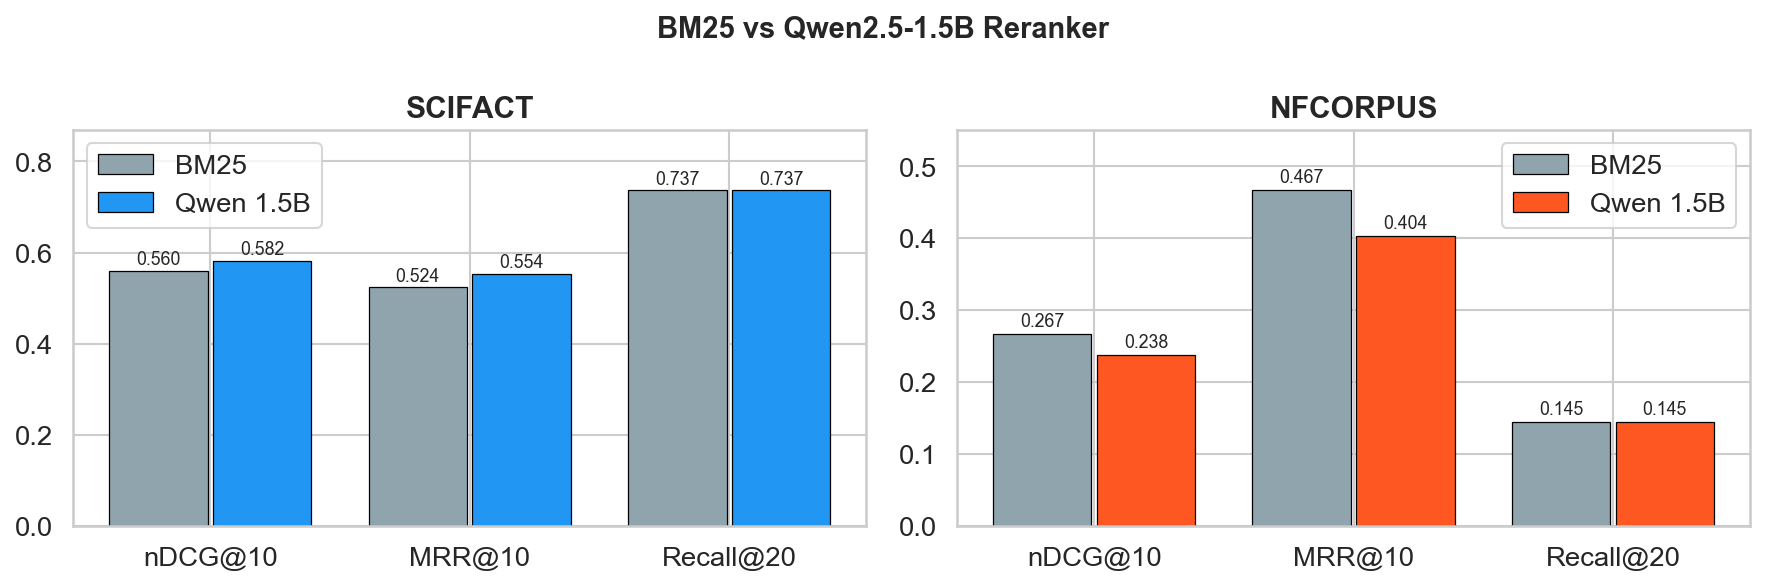

In [3]:
# Figure: grouped bar chart — BM25 vs Reranker, both datasets
metric_labels = {'ndcg@10': 'nDCG@10', 'mrr@10': 'MRR@10', 'recall@20': 'Recall@20'}
metric_keys   = list(metric_labels.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, ds in zip(axes, DATASETS):
    bm25_vals = [metrics_raw[ds]['bm25'][m] for m in metric_keys]
    rer_vals  = [metrics_raw[ds]['reranker'][m] for m in metric_keys]
    x = np.arange(len(metric_keys))
    bars1 = ax.bar(x - 0.2, bm25_vals, 0.38, label='BM25',     color='#90A4AE', edgecolor='black', lw=0.6)
    bars2 = ax.bar(x + 0.2, rer_vals,  0.38, label='Qwen 1.5B', color=COLORS[ds], edgecolor='black', lw=0.6)
    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x)
    ax.set_xticklabels([metric_labels[m] for m in metric_keys])
    ax.set_title(f'{ds.upper()}', fontweight='bold')
    ax.set_ylim(0, max(max(bm25_vals), max(rer_vals)) * 1.18)
    ax.legend()

fig.suptitle('BM25 vs Qwen2.5-1.5B Reranker', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_OUT / 'fig1_retrieval_comparison.png')
plt.show()

In [4]:
# LaTeX table
latex_rows = []
for ds in DATASETS:
    for method in ['bm25', 'reranker']:
        m = metrics_raw[ds][method]
        delta_n = metrics_raw[ds]['reranker']['ndcg@10'] - metrics_raw[ds]['bm25']['ndcg@10']
        delta_m = metrics_raw[ds]['reranker']['mrr@10']  - metrics_raw[ds]['bm25']['mrr@10']
        label = 'BM25' if method == 'bm25' else 'Qwen2.5-1.5B'
        row = {'Dataset': ds.upper(), 'Method': label,
               'nDCG@10': f"{m['ndcg@10']:.4f}",
               'MRR@10':  f"{m['mrr@10']:.4f}",
               'Recall@20': f"{m['recall@20']:.4f}"}
        if method == 'reranker':
            row['ΔnDCG'] = f"{delta_n:+.4f}"
            row['ΔMRR']  = f"{delta_m:+.4f}"
        else:
            row['ΔnDCG'] = '—'
            row['ΔMRR']  = '—'
        latex_rows.append(row)

table1 = pd.DataFrame(latex_rows)
table1.to_csv(TAB_OUT / 'table1_retrieval_metrics.csv', index=False)
print(table1.to_string(index=False))
print('\nSaved table1_retrieval_metrics.csv')

 Dataset       Method nDCG@10 MRR@10 Recall@20   ΔnDCG    ΔMRR
 SCIFACT         BM25  0.5597 0.5242    0.7370       —       —
 SCIFACT Qwen2.5-1.5B  0.5817 0.5537    0.7370 +0.0220 +0.0295
NFCORPUS         BM25  0.2666 0.4669    0.1446       —       —
NFCORPUS Qwen2.5-1.5B  0.2381 0.4039    0.1446 -0.0285 -0.0631

Saved table1_retrieval_metrics.csv


---
## 2. Reranker Score Distributions

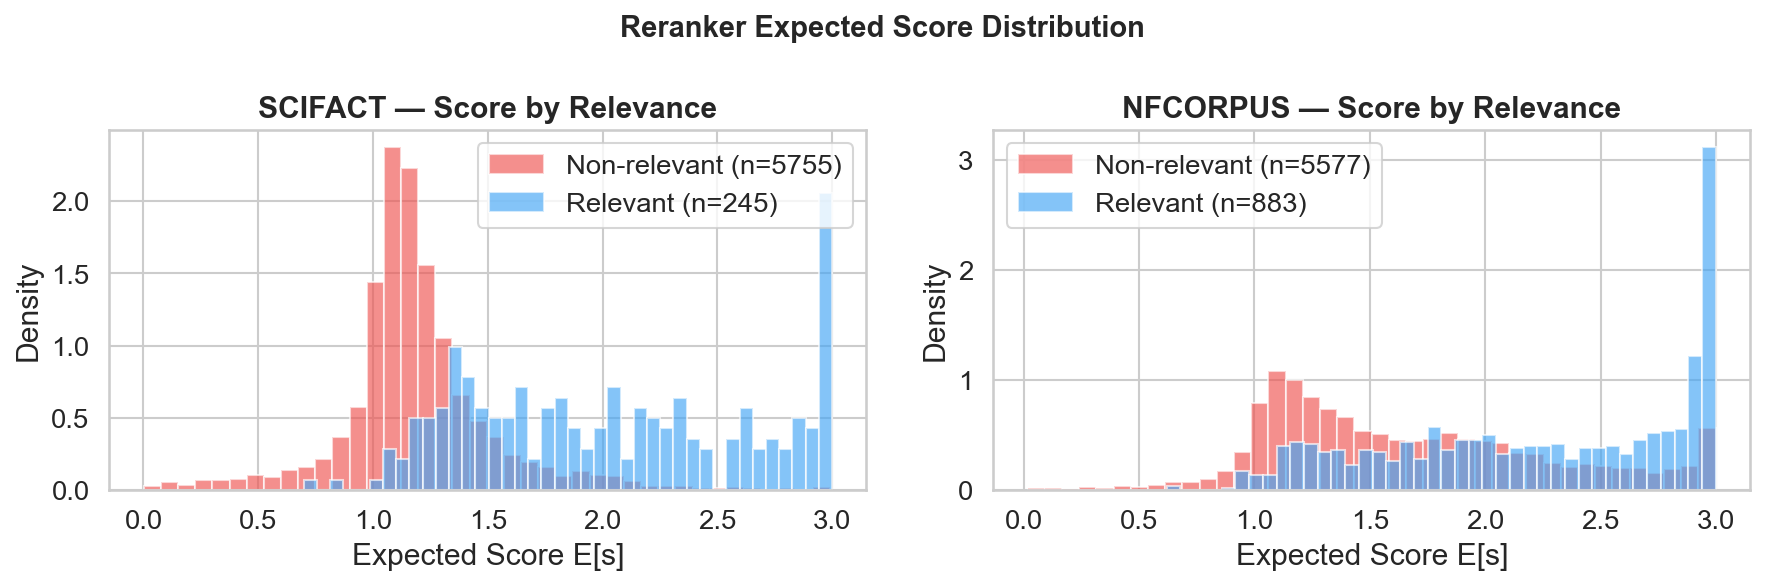

In [5]:
scores_dfs = {ds: pd.read_parquet(PROCESSED / ds / 'reranker_scores.parquet') for ds in DATASETS}
pairs_dfs  = {ds: pd.read_parquet(INTERIM / ds / 'query_doc_pairs.parquet')   for ds in DATASETS}

# Merge to get relevance labels
merged = {}
for ds in DATASETS:
    merged[ds] = scores_dfs[ds].merge(
        pairs_dfs[ds][['query_id', 'doc_id', 'is_relevant', 'relevance_label']],
        on=['query_id', 'doc_id']
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ds in zip(axes, DATASETS):
    df = merged[ds]
    for rel, label, color in [(0, 'Non-relevant', '#EF5350'), (1, 'Relevant', '#42A5F5')]:
        sub = df[df['is_relevant'] == rel]['reranker_expected_score']
        ax.hist(sub, bins=40, alpha=0.65, label=f'{label} (n={len(sub)})', color=color, density=True)
    ax.set_xlabel('Expected Score E[s]')
    ax.set_ylabel('Density')
    ax.set_title(f'{ds.upper()} — Score by Relevance', fontweight='bold')
    ax.legend()

fig.suptitle('Reranker Expected Score Distribution', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_OUT / 'fig2_score_distributions.png')
plt.show()

---
## 3. Probe Heatmaps — Layerwise Signal Emergence

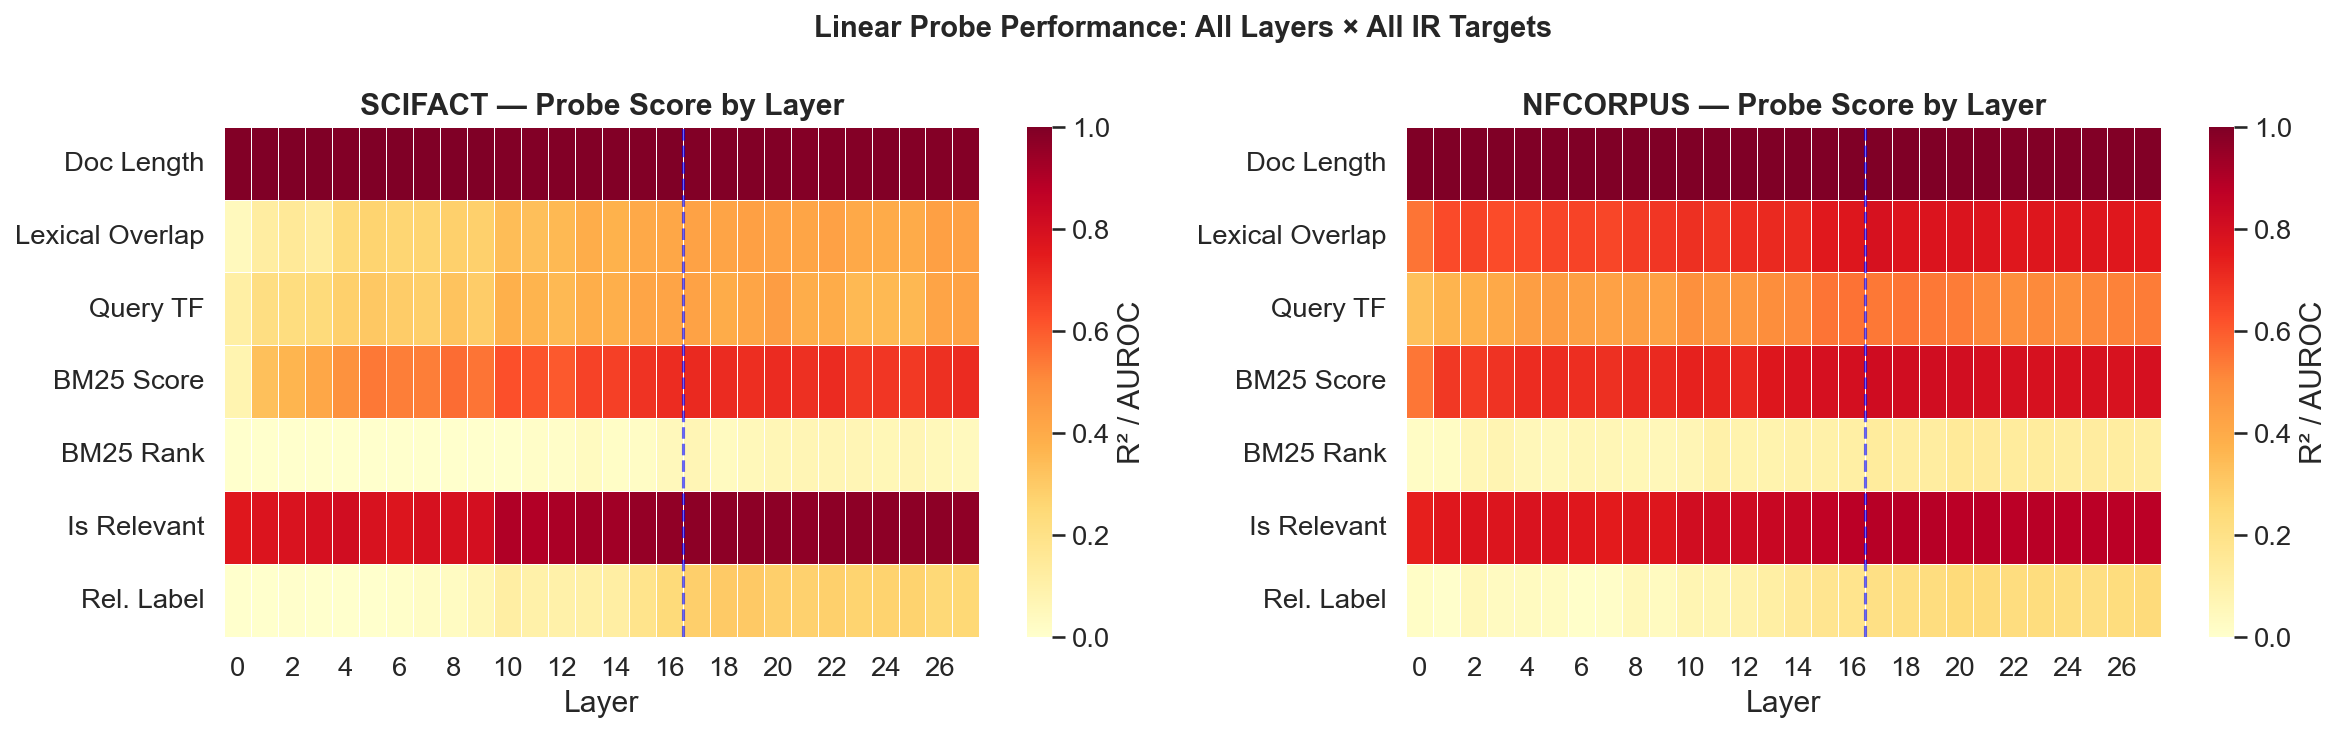

Blue dashed line = Layer 17 (confirmed peak)


In [6]:
probe_dfs = {}
for ds in DATASETS:
    with open(PROCESSED / ds / 'probe_results.json') as f:
        probe_dfs[ds] = pd.DataFrame(json.load(f))

TARGET_ORDER = ['doc_length_bucket', 'lexical_overlap', 'query_term_freq',
                'bm25_score', 'bm25_rank', 'is_relevant', 'relevance_label']
TARGET_LABELS = {
    'doc_length_bucket': 'Doc Length',
    'lexical_overlap':   'Lexical Overlap',
    'query_term_freq':   'Query TF',
    'bm25_score':        'BM25 Score',
    'bm25_rank':         'BM25 Rank',
    'is_relevant':       'Is Relevant',
    'relevance_label':   'Rel. Label'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, ds in zip(axes, DATASETS):
    pdf = probe_dfs[ds]
    pivot = pdf.pivot_table(index='target', columns='layer', values='score')
    pivot = pivot.reindex([t for t in TARGET_ORDER if t in pivot.index])
    pivot.index = [TARGET_LABELS.get(t, t) for t in pivot.index]
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'R² / AUROC'})
    ax.set_title(f'{ds.upper()} — Probe Score by Layer', fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel('')
    ax.axvline(x=17, color='blue', linewidth=1.5, linestyle='--', alpha=0.6)

fig.suptitle('Linear Probe Performance: All Layers × All IR Targets', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_OUT / 'fig3_probe_heatmaps.png')
plt.show()
print('Blue dashed line = Layer 17 (confirmed peak)')

---
## 4. Peak Probe Scores — Table

In [7]:
peak_rows = []
for ds in DATASETS:
    pdf = probe_dfs[ds]
    for target in TARGET_ORDER:
        sub = pdf[pdf['target'] == target]
        if sub.empty:
            continue
        best = sub.loc[sub['score'].idxmax()]
        metric = 'AUROC' if best['probe_type'] == 'logistic' else 'R²'
        peak_rows.append({
            'Dataset': ds.upper(),
            'Target': TARGET_LABELS.get(target, target),
            'Metric': metric,
            'Peak Score': round(best['score'], 4),
            '95% CI': f"[{best['ci_lower']:.3f}, {best['ci_upper']:.3f}]",
            'Peak Layer': int(best['layer'])
        })

peak_table = pd.DataFrame(peak_rows)
peak_table.to_csv(TAB_OUT / 'table2_peak_probe_scores.csv', index=False)
print(peak_table.to_string(index=False))

 Dataset          Target Metric  Peak Score         95% CI  Peak Layer
 SCIFACT      Doc Length  AUROC      0.9976 [0.996, 0.999]           3
 SCIFACT Lexical Overlap     R²      0.4374 [0.391, 0.478]          19
 SCIFACT        Query TF     R²      0.4466 [0.398, 0.491]          20
 SCIFACT      BM25 Score     R²      0.7147 [0.684, 0.740]          17
 SCIFACT       BM25 Rank     R²      0.0694 [0.021, 0.119]          17
 SCIFACT     Is Relevant  AUROC      0.9709 [0.954, 0.984]          17
 SCIFACT      Rel. Label     R²      0.3022 [0.166, 0.409]          19
NFCORPUS      Doc Length  AUROC      0.9994 [0.999, 1.000]           1
NFCORPUS Lexical Overlap     R²      0.7912 [0.769, 0.811]          17
NFCORPUS        Query TF     R²      0.5516 [0.508, 0.596]          16
NFCORPUS      BM25 Score     R²      0.8141 [0.793, 0.833]          17
NFCORPUS       BM25 Rank     R²      0.1459 [0.096, 0.193]          20
NFCORPUS     Is Relevant  AUROC      0.8861 [0.858, 0.910]          17
NFCORP

---
## 5. Layer Story — How Signals Emerge Across Layers

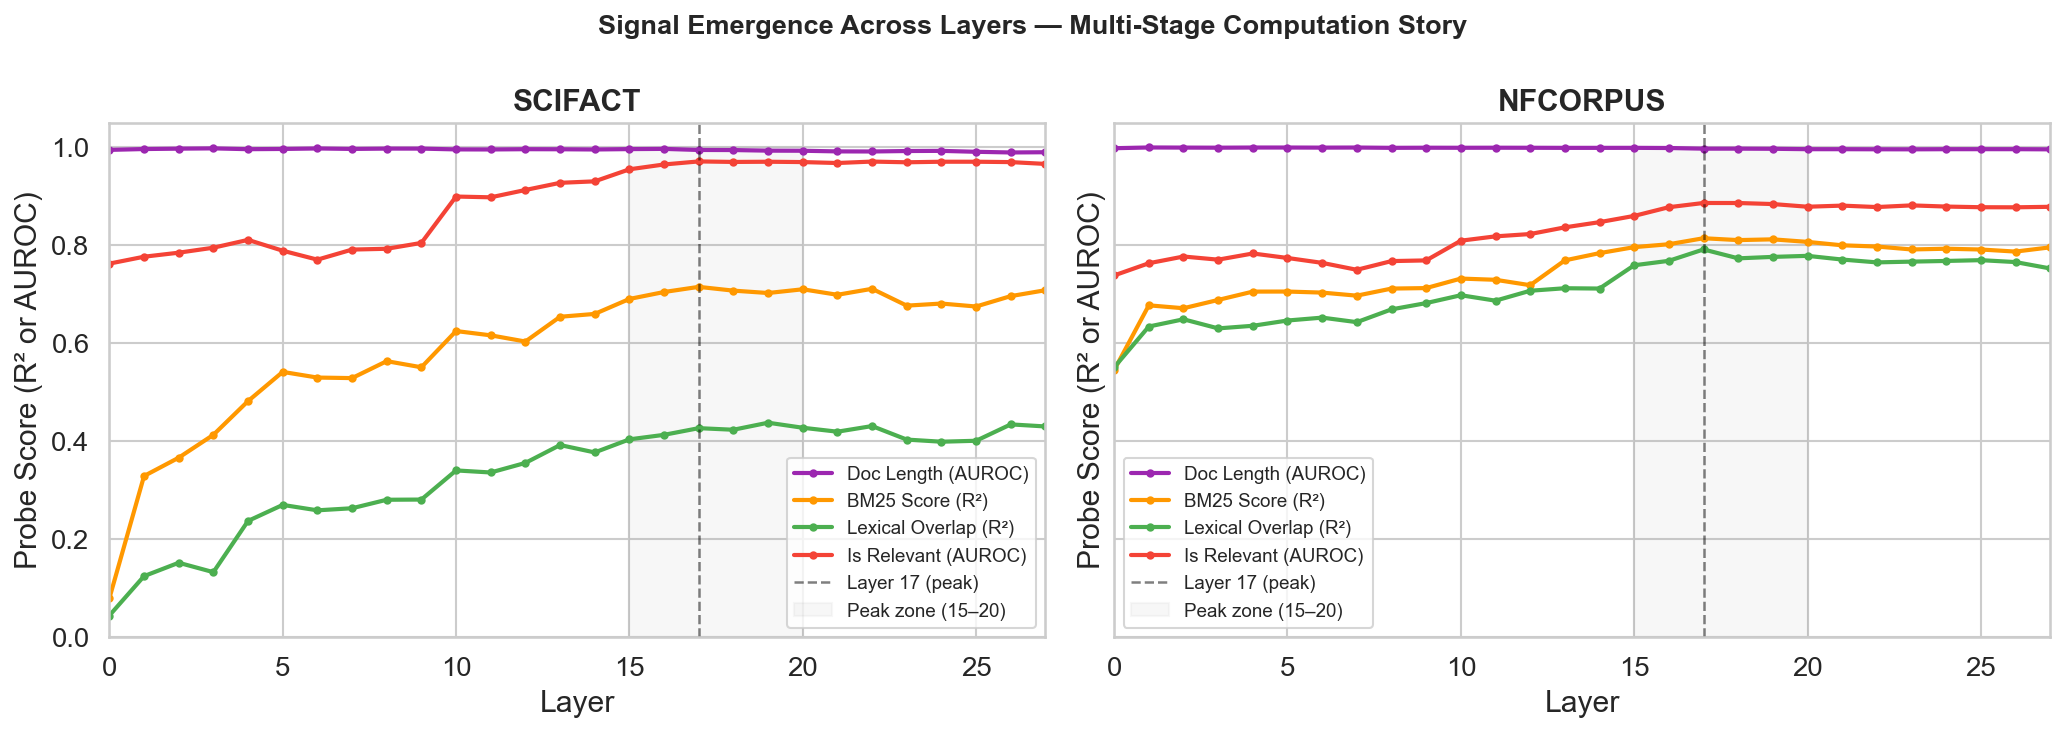

In [8]:
# Focus targets that tell the clearest story
story_targets = {
    'doc_length_bucket': ('Doc Length (AUROC)', '#9C27B0'),
    'bm25_score':        ('BM25 Score (R²)',    '#FF9800'),
    'lexical_overlap':   ('Lexical Overlap (R²)','#4CAF50'),
    'is_relevant':       ('Is Relevant (AUROC)', '#F44336'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ds in zip(axes, DATASETS):
    pdf = probe_dfs[ds]
    for target, (label, color) in story_targets.items():
        sub = pdf[pdf['target'] == target].sort_values('layer')
        ax.plot(sub['layer'], sub['score'], label=label, color=color, linewidth=2, marker='o', markersize=3)
    ax.axvline(x=17, color='black', linewidth=1.2, linestyle='--', alpha=0.5, label='Layer 17 (peak)')
    ax.fill_betweenx([0, 1], 15, 20, alpha=0.06, color='gray', label='Peak zone (15–20)')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Probe Score (R² or AUROC)')
    ax.set_title(f'{ds.upper()}', fontweight='bold')
    ax.set_xlim(0, 27)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

fig.suptitle('Signal Emergence Across Layers — Multi-Stage Computation Story',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_OUT / 'fig4_layer_story.png')
plt.show()

---
## 6. Cross-Dataset Probe Generalization

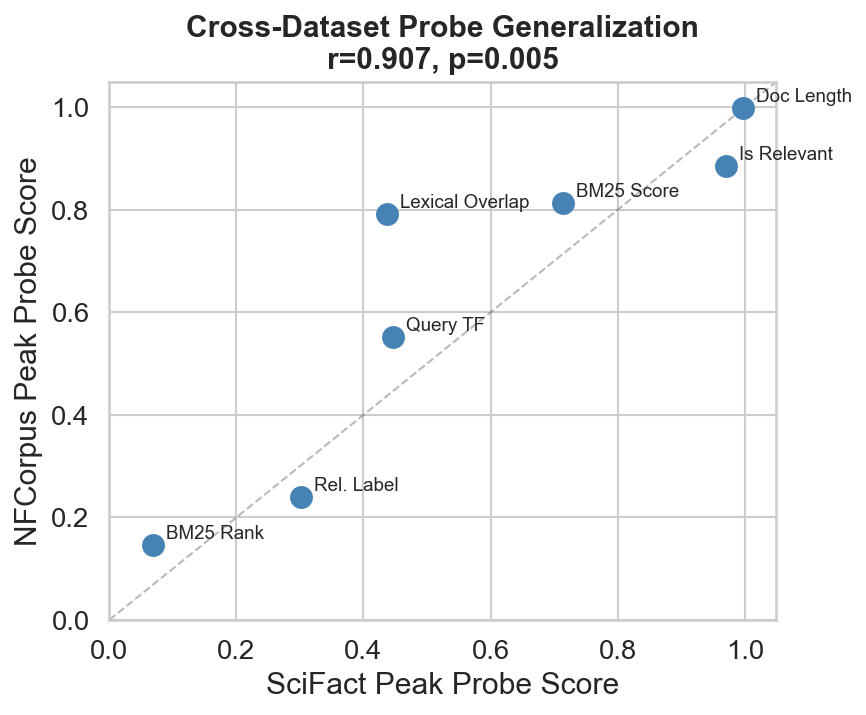

In [9]:
# Scatter: SciFact peak score vs NFCorpus peak score per target
sf_peak = probe_dfs['scifact'].groupby('target')['score'].max().rename('scifact')
nf_peak = probe_dfs['nfcorpus'].groupby('target')['score'].max().rename('nfcorpus')
cross = pd.concat([sf_peak, nf_peak], axis=1).dropna()

r, p = pearsonr(cross['scifact'], cross['nfcorpus'])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(cross['scifact'], cross['nfcorpus'], s=100, color='steelblue', zorder=3)
for t, row in cross.iterrows():
    ax.annotate(TARGET_LABELS.get(t, t), (row['scifact'], row['nfcorpus']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
lim = [0, 1.05]
ax.plot(lim, lim, 'k--', alpha=0.3, linewidth=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('SciFact Peak Probe Score')
ax.set_ylabel('NFCorpus Peak Probe Score')
ax.set_title(f'Cross-Dataset Probe Generalization\nr={r:.3f}, p={p:.3f}', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_OUT / 'fig5_cross_dataset_probe.png')
plt.show()

---
## 7. SAE Analysis — Reconstruction Quality

 Dataset  Layer  Val Loss (MSE)  Train Loss  Hidden Dim  k (TopK)
 SCIFACT      7          0.1388      0.1377        6144        64
 SCIFACT     17          0.2813      0.2817        3072        64
 SCIFACT     21          0.6576      0.6582        3072        64
NFCORPUS      7          0.1120      0.1107        6144        64
NFCORPUS     17          0.2498      0.2502        3072        64
NFCORPUS     21          0.5940      0.5953        3072        64


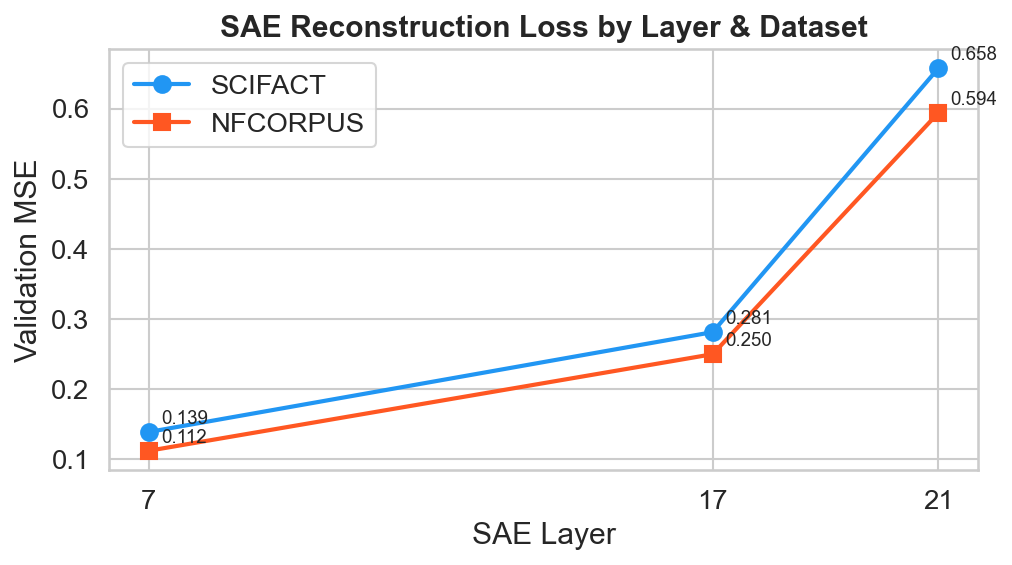

In [10]:
sae_meta = {}
for ds in DATASETS:
    sae_meta[ds] = {}
    for layer in [7, 17, 21]:
        with open(FINAL / f'sae_checkpoints/{ds}/layer{layer}/metadata.json') as f:
            sae_meta[ds][layer] = json.load(f)

rows = []
for ds in DATASETS:
    for layer in [7, 17, 21]:
        m = sae_meta[ds][layer]
        rows.append({'Dataset': ds.upper(), 'Layer': layer,
                     'Val Loss (MSE)': round(m['val_loss'], 4),
                     'Train Loss':     round(m['train_loss'], 4),
                     'Hidden Dim':     m['hidden_dim'],
                     'k (TopK)':       m['k']})
sae_meta_df = pd.DataFrame(rows)
sae_meta_df.to_csv(TAB_OUT / 'table3_sae_training_metrics.csv', index=False)
print(sae_meta_df.to_string(index=False))

# Figure
fig, ax = plt.subplots(figsize=(7, 4))
for ds, marker in zip(DATASETS, ['o', 's']):
    sub = sae_meta_df[sae_meta_df['Dataset'] == ds.upper()]
    ax.plot(sub['Layer'], sub['Val Loss (MSE)'], marker=marker, color=COLORS[ds],
            linewidth=2, markersize=8, label=ds.upper())
    for _, row in sub.iterrows():
        ax.annotate(f"{row['Val Loss (MSE)']:.3f}",
                    (row['Layer'], row['Val Loss (MSE)']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('SAE Layer'); ax.set_ylabel('Validation MSE')
ax.set_xticks([7, 17, 21])
ax.set_title('SAE Reconstruction Loss by Layer & Dataset', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_OUT / 'fig6_sae_reconstruction.png')
plt.show()

---
## 8. SAE IR Correlation Heatmap — Layer 17

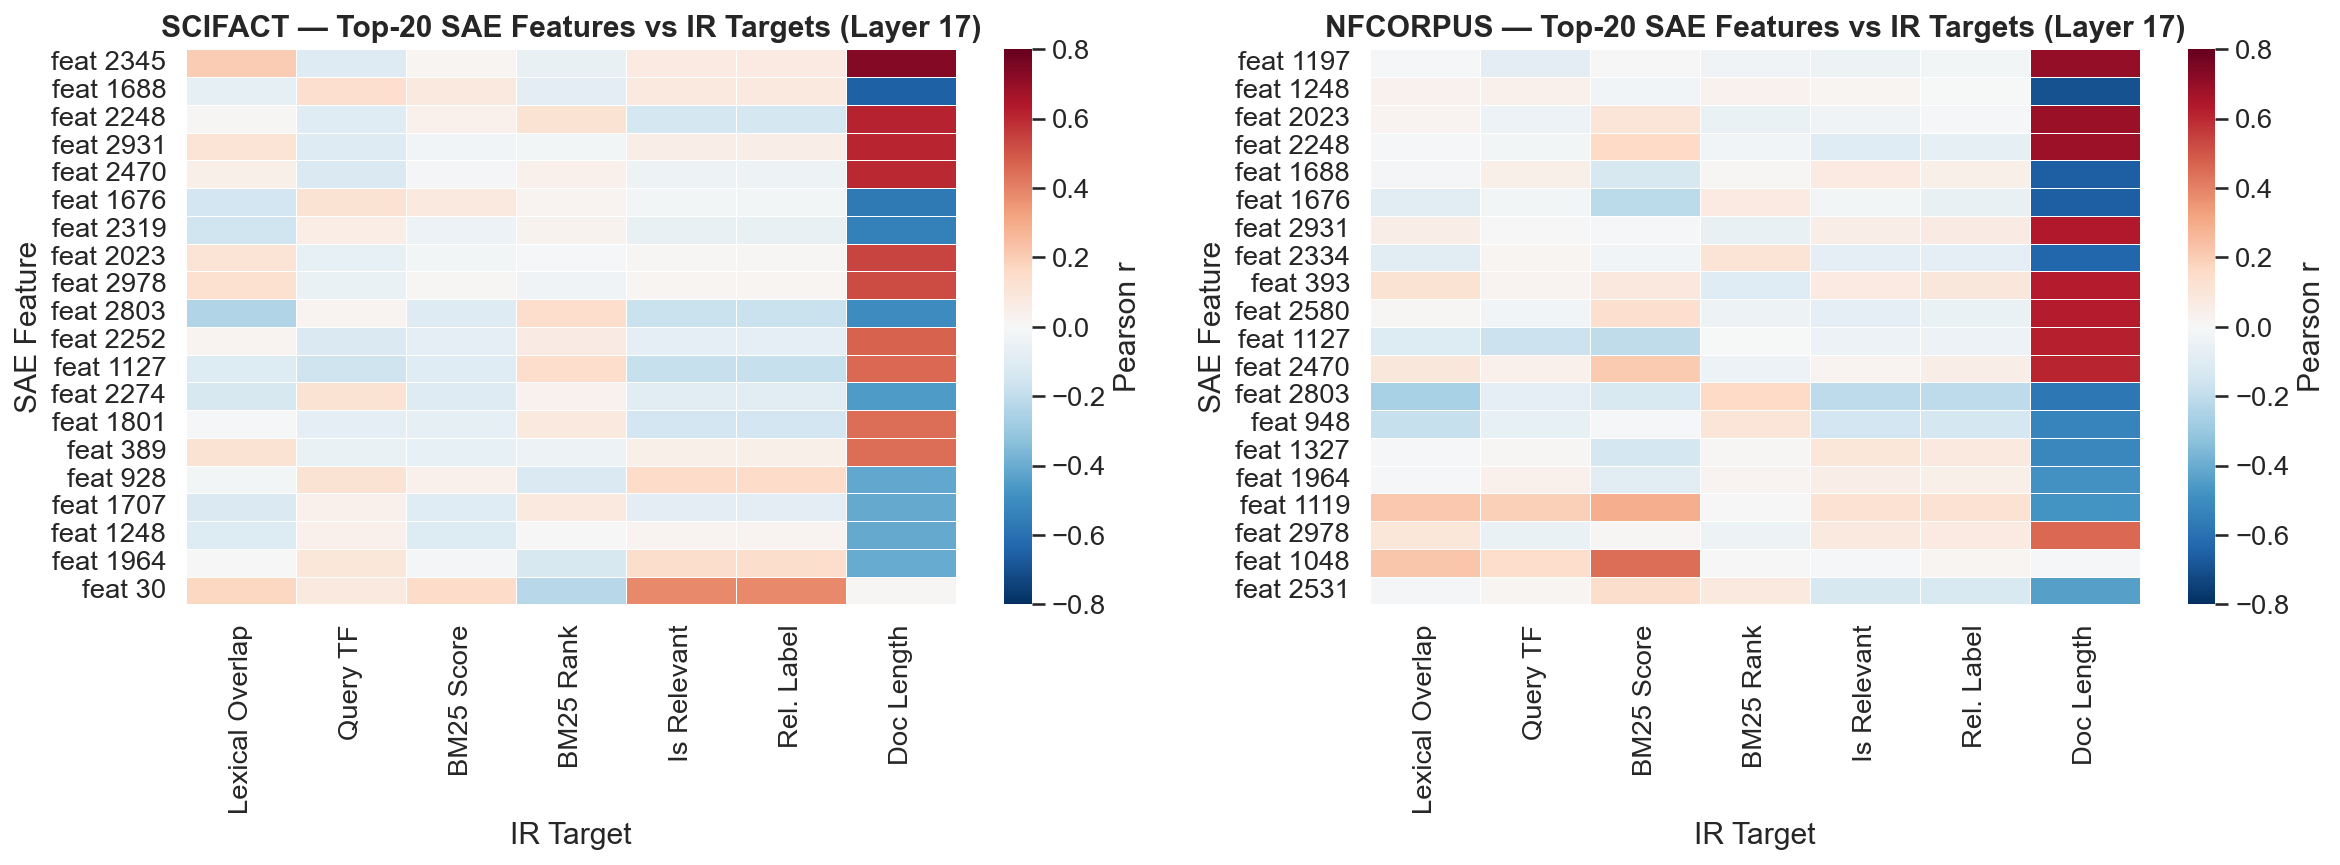

In [11]:
sae_corr = {}
for ds in DATASETS:
    sae_corr[ds] = pd.read_parquet(FINAL / f'sae_analysis/{ds}/ir_correlations_layer17.parquet')

# Top-20 features by max |r| across any target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
r_cols = [c for c in sae_corr['scifact'].columns if c.startswith('r_')]
col_labels = {c: TARGET_LABELS.get(c[2:], c[2:]) for c in r_cols}

for ax, ds in zip(axes, DATASETS):
    df = sae_corr[ds][r_cols]
    top_feats = df.abs().max(axis=1).nlargest(20).index
    heat = df.loc[top_feats]
    heat.columns = [col_labels[c] for c in heat.columns]
    heat.index = [f'feat {i}' for i in heat.index]
    sns.heatmap(heat, ax=ax, cmap='RdBu_r', center=0, vmin=-0.8, vmax=0.8,
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Pearson r'})
    ax.set_title(f'{ds.upper()} — Top-20 SAE Features vs IR Targets (Layer 17)',
                 fontweight='bold')
    ax.set_xlabel('IR Target')
    ax.set_ylabel('SAE Feature')

plt.tight_layout()
plt.savefig(FIG_OUT / 'fig7_sae_ir_correlations.png')
plt.show()

---
## 9. Top SAE Feature Per Target — Cross-Dataset Consistency

In [12]:
top_feature_rows = []
for ds in DATASETS:
    df = sae_corr[ds]
    for col in r_cols:
        target = col[2:]
        best_idx = int(df[col].abs().idxmax())
        r_val = float(df.loc[best_idx, col])
        top_feature_rows.append({
            'Dataset': ds.upper(),
            'IR Target': TARGET_LABELS.get(target, target),
            'Feature Idx': best_idx,
            'Pearson r': round(r_val, 3)
        })

top_feat_df = pd.DataFrame(top_feature_rows)
top_feat_df.to_csv(TAB_OUT / 'table4_top_sae_features.csv', index=False)

# Pivot to compare datasets side by side
pivot = top_feat_df.pivot_table(index='IR Target', columns='Dataset',
                                 values=['Feature Idx', 'Pearson r'], aggfunc='first')
print('=== Top SAE Feature per IR Target (Layer 17) ===')
print(pivot.to_string())

# Highlight shared features
sf_feats = top_feat_df[top_feat_df['Dataset']=='SCIFACT'].set_index('IR Target')['Feature Idx']
nf_feats = top_feat_df[top_feat_df['Dataset']=='NFCORPUS'].set_index('IR Target')['Feature Idx']
shared = set(sf_feats.values) & set(nf_feats.values)
print(f'\nFeatures shared across both datasets: {shared}')
for fidx in shared:
    sf_t = sf_feats[sf_feats == fidx].index.tolist()
    nf_t = nf_feats[nf_feats == fidx].index.tolist()
    print(f'  Feature {fidx}: top for {sf_t} (SciFact) and {nf_t} (NFCorpus)')

=== Top SAE Feature per IR Target (Layer 17) ===
                Feature Idx         Pearson r        
Dataset            NFCORPUS SCIFACT  NFCORPUS SCIFACT
IR Target                                            
BM25 Rank              2803     656     0.158   0.251
BM25 Score             1048    2166     0.447  -0.292
Doc Length             1197    2345     0.705   0.734
Is Relevant              30      30     0.292   0.382
Lexical Overlap        2252     746    -0.276  -0.241
Query TF                928    1127     0.231  -0.164
Rel. Label               30      30     0.260   0.382

Features shared across both datasets: {np.int64(30)}
  Feature 30: top for ['Is Relevant', 'Rel. Label'] (SciFact) and ['Is Relevant', 'Rel. Label'] (NFCorpus)


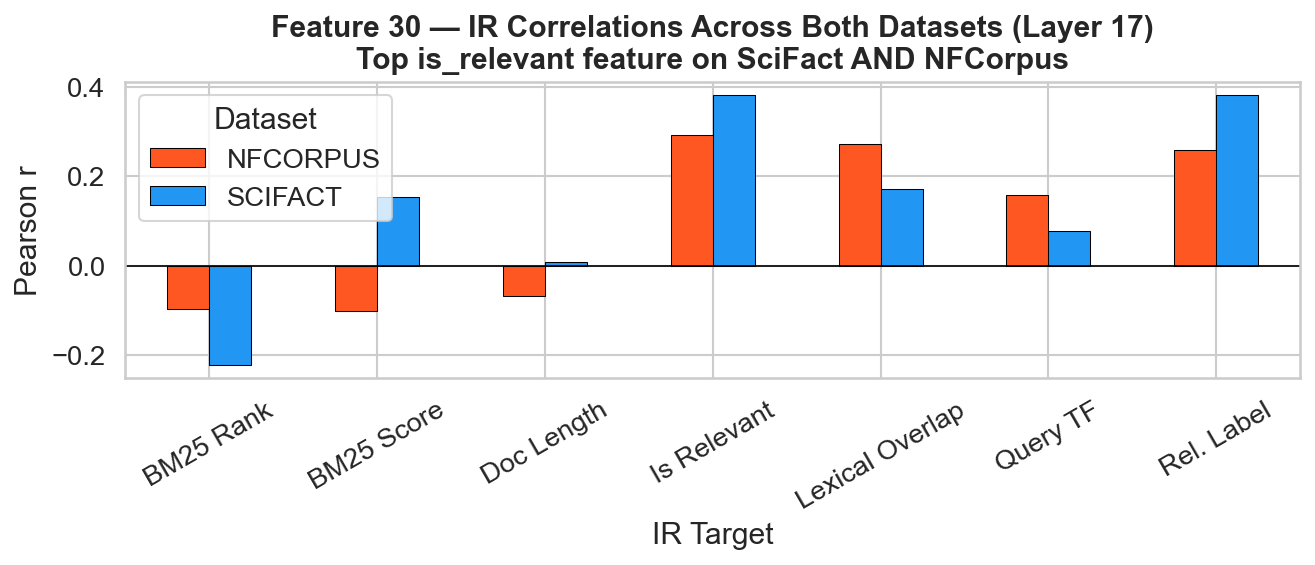

In [13]:
# Figure: cross-dataset feature correlation comparison for is_relevant
# Feature 30 is top for is_relevant on BOTH datasets — visualise its r across all targets
feat30_rows = []
for ds in DATASETS:
    df = sae_corr[ds]
    if 30 in df.index:
        for col in r_cols:
            feat30_rows.append({'Dataset': ds.upper(),
                                'IR Target': TARGET_LABELS.get(col[2:], col[2:]),
                                'Pearson r': float(df.loc[30, col])})

feat30_df = pd.DataFrame(feat30_rows)
fig, ax = plt.subplots(figsize=(9, 4))
feat30_pivot = feat30_df.pivot(index='IR Target', columns='Dataset', values='Pearson r')
feat30_pivot.plot(kind='bar', ax=ax, color=[COLORS[d.lower()] for d in feat30_pivot.columns],
                  edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('IR Target'); ax.set_ylabel('Pearson r')
ax.set_title('Feature 30 — IR Correlations Across Both Datasets (Layer 17)\n'
             'Top is_relevant feature on SciFact AND NFCorpus', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Dataset')
plt.tight_layout()
plt.savefig(FIG_OUT / 'fig8_feature30_cross_dataset.png')
plt.show()

---
## 10. Causal Interventions (Phase 8)
*Loads from* `outputs/final/interventions/{scifact,nfcorpus}/` — all data pre-saved, no model runs needed.

In [14]:
# Load intervention results for both datasets
int_data = {}
for ds in DATASETS:
    int_dir = FINAL / f'interventions/{ds}'
    if (int_dir / 'probe_intervention_results.json').exists():
        with open(int_dir / 'baseline_metrics.json') as f:
            baseline = json.load(f)
        with open(int_dir / 'probe_intervention_results.json') as f:
            probe_df = pd.DataFrame(json.load(f))
        with open(int_dir / 'sae_intervention_results.json') as f:
            sae_df = pd.DataFrame(json.load(f))
        int_data[ds] = {'baseline': baseline, 'probe': probe_df, 'sae': sae_df}
        print(f"{ds.upper()}: {len(probe_df)} probe, {len(sae_df)} SAE conditions | "
              f"split-pass baseline nDCG@10={probe_df['split_baseline_ndcg'].iloc[0]:.4f}")
    else:
        print(f"{ds.upper()}: not found")

phase8_available = len(int_data) > 0

SCIFACT: 18 probe, 12 SAE conditions | split-pass baseline nDCG@10=0.2217
NFCORPUS: 18 probe, 12 SAE conditions | split-pass baseline nDCG@10=0.1467


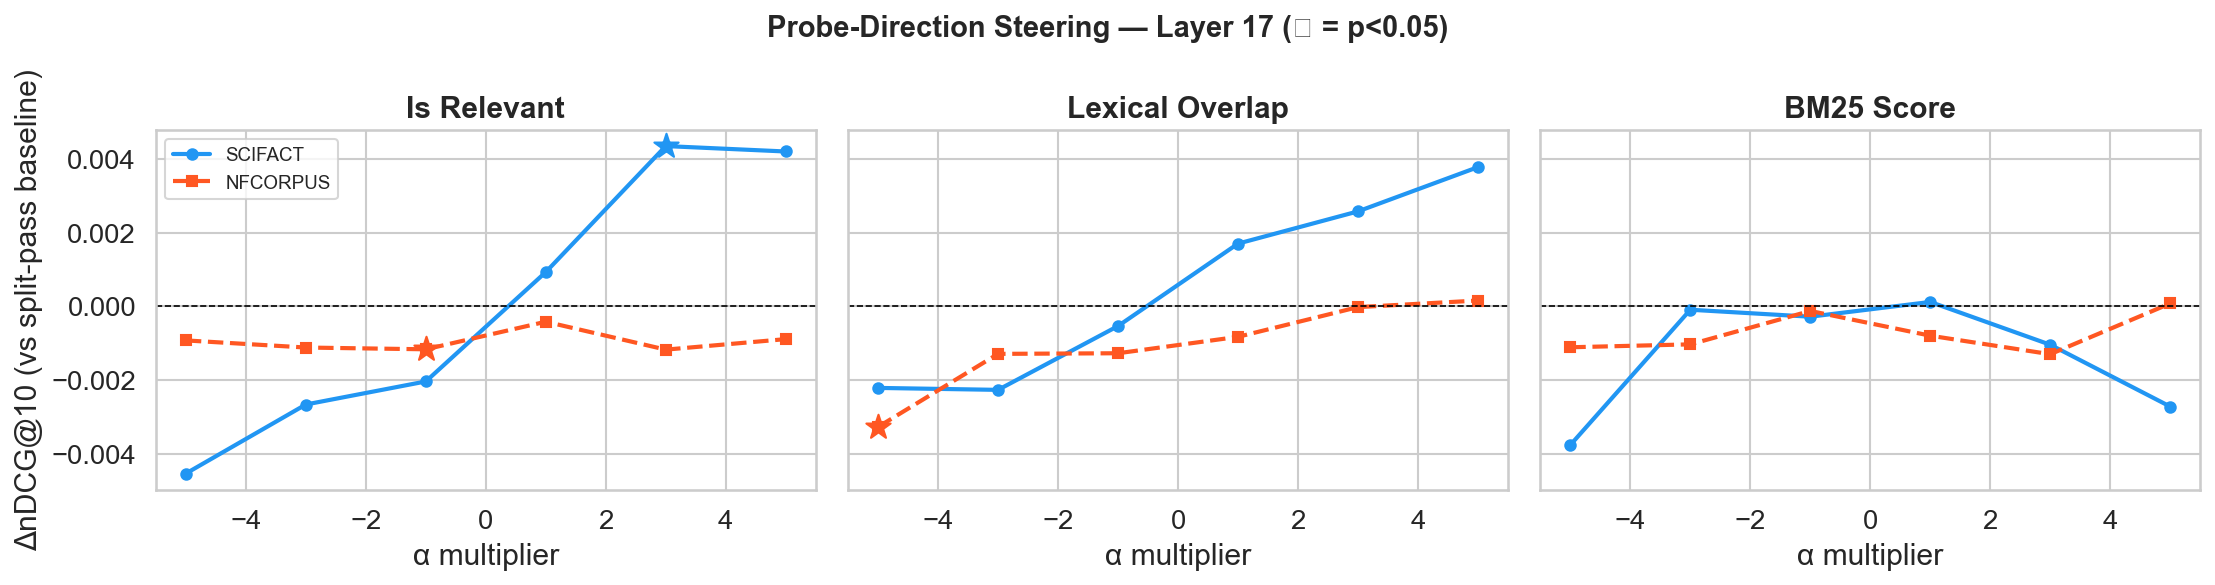

In [15]:
if phase8_available:
    # Dose-response curves — both datasets side by side per target
    targets_int = ['is_relevant', 'lexical_overlap', 'bm25_score']
    colors_ds = {'scifact': COLORS['scifact'], 'nfcorpus': COLORS['nfcorpus']}

    fig, axes = plt.subplots(1, len(targets_int), figsize=(5*len(targets_int), 4), sharey=True)
    for ax, target in zip(axes, targets_int):
        for ds, style in zip(DATASETS, ['-o', '--s']):
            if ds not in int_data: continue
            sub = int_data[ds]['probe']
            sub = sub[sub['target'] == target].sort_values('alpha_multiplier')
            ax.plot(sub['alpha_multiplier'], sub['delta_ndcg'],
                    style, color=colors_ds[ds], linewidth=2, markersize=5, label=ds.upper())
            sig = sub[sub['significant']]
            if len(sig):
                ax.scatter(sig['alpha_multiplier'], sig['delta_ndcg'],
                           s=150, marker='*', color=colors_ds[ds], zorder=5)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(TARGET_LABELS.get(target, target), fontweight='bold')
        ax.set_xlabel('α multiplier')
        if target == targets_int[0]: ax.legend(fontsize=9)

    axes[0].set_ylabel('ΔnDCG@10 (vs split-pass baseline)')
    fig.suptitle('Probe-Direction Steering — Layer 17 (★ = p<0.05)', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'fig9_probe_dose_response.png')
    plt.show()

=== All Significant Causal Results (p<0.05) ===
 Dataset  Type               Signal    α     ΔnDCG      p
 SCIFACT Probe          Is Relevant  3.0  0.004344 0.0483
 SCIFACT   SAE feat30 (Is Relevant)  NaN -0.003816 0.0461
NFCORPUS Probe          Is Relevant -1.0 -0.001167 0.0384
NFCORPUS Probe      Lexical Overlap -5.0 -0.003271 0.0282


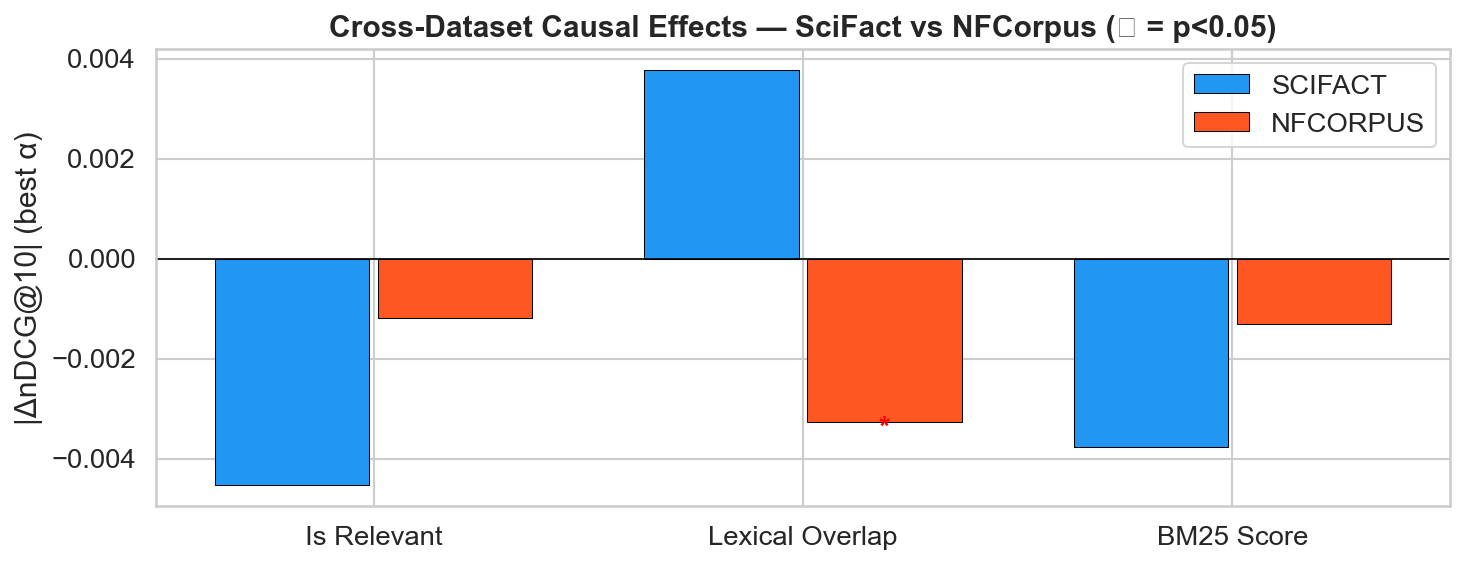

Key finding: is_relevant causally dominant on SciFact; lexical_overlap on NFCorpus (OOD shift)


In [16]:
if phase8_available:
    # Cross-dataset significant findings comparison
    sig_rows = []
    for ds in DATASETS:
        if ds not in int_data: continue
        for _, row in int_data[ds]['probe'][int_data[ds]['probe']['significant']].iterrows():
            sig_rows.append({'Dataset': ds.upper(), 'Type': 'Probe',
                             'Signal': TARGET_LABELS.get(row['target'], row['target']),
                             'α': row['alpha_multiplier'], 'ΔnDCG': row['delta_ndcg'],
                             'p': row['p_value']})
        for _, row in int_data[ds]['sae'][int_data[ds]['sae']['significant']].iterrows():
            sig_rows.append({'Dataset': ds.upper(), 'Type': 'SAE',
                             'Signal': f"feat{row['feature_idx']} ({TARGET_LABELS.get(row['ir_target'], row['ir_target'])})",
                             'α': row.get('alpha', 'ablate'), 'ΔnDCG': row['delta_ndcg'],
                             'p': row['p_value']})

    if sig_rows:
        sig_summary = pd.DataFrame(sig_rows)
        print('=== All Significant Causal Results (p<0.05) ===')
        print(sig_summary.to_string(index=False))
        sig_summary.to_csv(TAB_OUT / 'table5_significant_causal_results.csv', index=False)

    # Bar chart: best |ΔnDCG| per (dataset, target)
    best_probe_both = []
    for ds in DATASETS:
        if ds not in int_data: continue
        probe_df = int_data[ds]['probe']
        idx = probe_df.groupby('target')['delta_ndcg'].apply(lambda x: x.abs().idxmax())
        best = probe_df.loc[idx].copy()[['target', 'delta_ndcg', 'significant']]
        best['dataset'] = ds.upper()
        best_probe_both.append(best)
    best_probe_both = pd.concat(best_probe_both).reset_index(drop=True)

    targets_sorted = ['is_relevant', 'lexical_overlap', 'bm25_score']
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(targets_sorted))
    for i, ds in enumerate(DATASETS):
        sub = best_probe_both[best_probe_both['dataset']==ds.upper()].set_index('target')
        vals = [float(sub.loc[t, 'delta_ndcg']) if t in sub.index else 0 for t in targets_sorted]
        sigs = [bool(sub.loc[t, 'significant']) if t in sub.index else False for t in targets_sorted]
        bars = ax.bar(x+(i-0.5)*0.38, vals, 0.36, label=ds.upper(),
                      color=COLORS[ds], edgecolor='black', lw=0.5)
        for bar, sig in zip(bars, sigs):
            if sig:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+(0.0001 if bar.get_height()>=0 else -0.0003),
                        '*', ha='center', fontsize=14, color='red', fontweight='bold')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABELS.get(t, t) for t in targets_sorted])
    ax.set_ylabel('|ΔnDCG@10| (best α)')
    ax.set_title('Cross-Dataset Causal Effects — SciFact vs NFCorpus (★ = p<0.05)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'fig10_cross_dataset_causal.png')
    plt.show()
    print('Key finding: is_relevant causally dominant on SciFact; lexical_overlap on NFCorpus (OOD shift)')

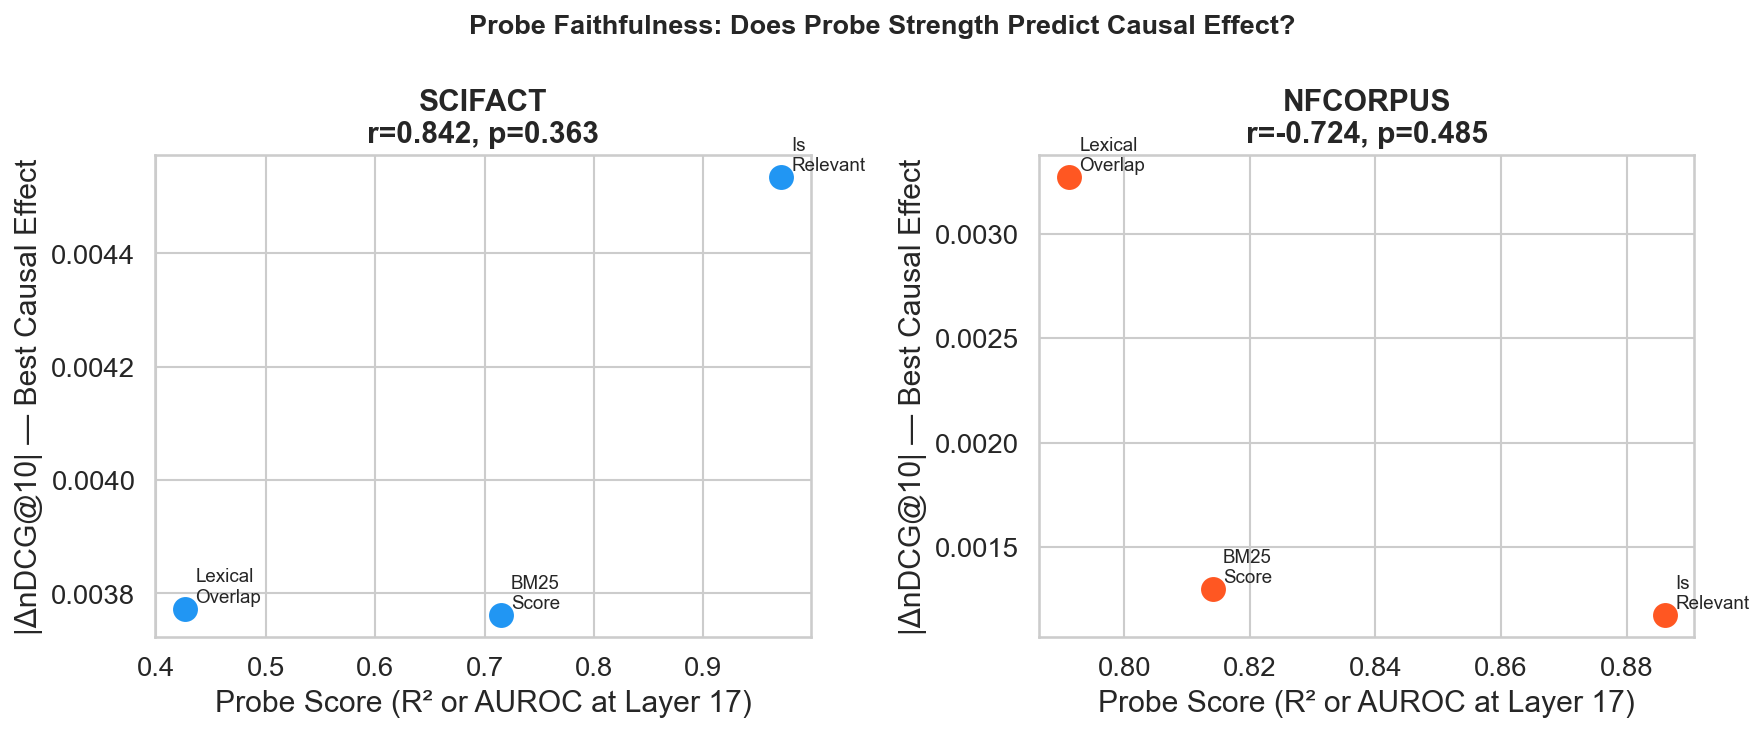

In [17]:
if phase8_available:
    # Probe faithfulness — both datasets on same plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, ds in zip(axes, [d for d in DATASETS if d in int_data]):
        peak_l17 = (probe_dfs[ds][probe_dfs[ds]['layer']==17]
                    .set_index('target')['score'])
        best_causal = (int_data[ds]['probe'][int_data[ds]['probe']['layer']==17]
                       .groupby('target')['delta_ndcg']
                       .apply(lambda x: x.abs().max()))
        faith = pd.concat([peak_l17.rename('probe_score'),
                           best_causal.rename('causal_delta')], axis=1).dropna()

        ax.scatter(faith['probe_score'], faith['causal_delta'],
                   s=120, color=COLORS[ds], zorder=3)
        for t, row in faith.iterrows():
            ax.annotate(TARGET_LABELS.get(t, t).replace(' ', '\n'),
                        (row['probe_score'], row['causal_delta']),
                        textcoords='offset points', xytext=(5, 3), fontsize=9)

        if len(faith) >= 3:
            r_f, p_f = pearsonr(faith['probe_score'], faith['causal_delta'])
            ax.set_title(f'{ds.upper()}\nr={r_f:.3f}, p={p_f:.3f}', fontweight='bold')
        else:
            ax.set_title(ds.upper(), fontweight='bold')

        ax.set_xlabel('Probe Score (R² or AUROC at Layer 17)')
        ax.set_ylabel('|ΔnDCG@10| — Best Causal Effect')

    fig.suptitle('Probe Faithfulness: Does Probe Strength Predict Causal Effect?',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'fig11_probe_faithfulness.png')
    plt.show()

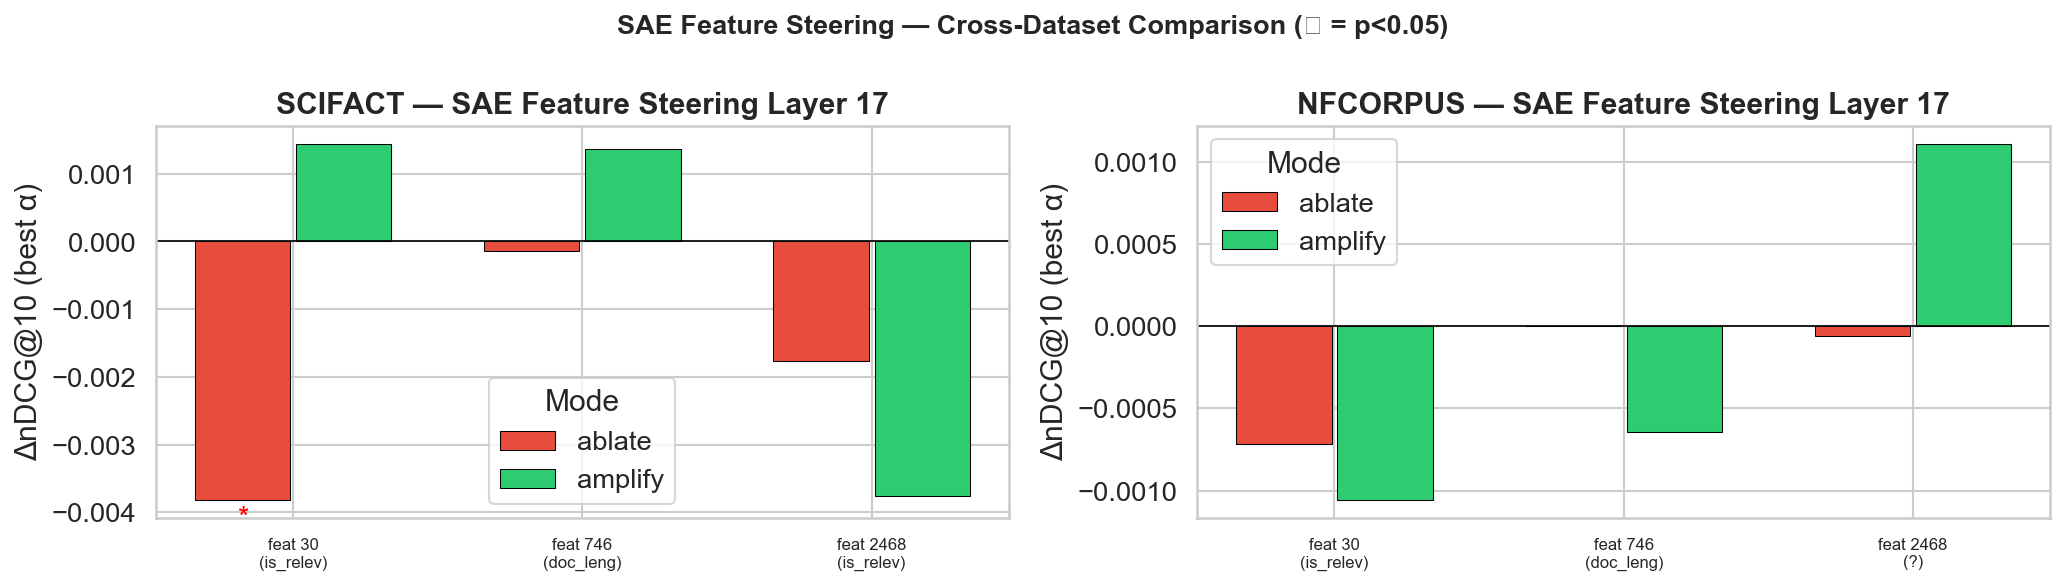

In [18]:
if phase8_available:
    palette_sae = {'ablate': '#e74c3c', 'amplify': '#2ecc71'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, ds in zip(axes, [d for d in DATASETS if d in int_data]):
        sae_df = int_data[ds]['sae']

        # Best per (feature_idx, mode) using idxmax to avoid pandas groupby.apply issues
        idx = sae_df.groupby(['feature_idx','mode'])['delta_ndcg'].apply(lambda x: x.abs().idxmax())
        best_sae = sae_df.loc[idx].copy().reset_index(drop=True)

        features = sorted(best_sae['feature_idx'].unique())
        x = np.arange(len(features))
        feat_labels = {}
        for _, row in sae_df[['feature_idx','ir_target']].drop_duplicates().iterrows():
            tgt = row['ir_target'] if row['ir_target'] != 'custom' else '?'
            feat_labels[row['feature_idx']] = f"feat {row['feature_idx']}\n({tgt[:8]})"

        for i, mode in enumerate(['ablate','amplify']):
            sub = best_sae[best_sae['mode']==mode].set_index('feature_idx').reindex(features)
            vals = sub['delta_ndcg'].fillna(0).values
            sigs = sub['significant'].fillna(False).values
            bars = ax.bar(x+(i-0.5)*0.35, vals, 0.33, label=mode,
                          color=palette_sae[mode], edgecolor='black', lw=0.5)
            for bar, sig in zip(bars, sigs):
                if sig:
                    ax.text(bar.get_x()+bar.get_width()/2,
                            bar.get_height()+(0.0002 if bar.get_height()>=0 else -0.0004),
                            '*', ha='center', fontsize=14, color='red')

        ax.axhline(0, color='black', lw=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([feat_labels.get(f, f'feat {f}') for f in features], fontsize=8)
        ax.set_title(f'{ds.upper()} — SAE Feature Steering Layer 17', fontweight='bold')
        ax.set_ylabel('ΔnDCG@10 (best α)')
        ax.legend(title='Mode')

    fig.suptitle('SAE Feature Steering — Cross-Dataset Comparison (★ = p<0.05)',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_OUT / 'fig12_sae_steering_effects.png')
    plt.show()

In [19]:
if phase8_available:
    print('=== Phase 8: All Significant Results ===\n')
    for ds in DATASETS:
        if ds not in int_data: continue
        probe_df = int_data[ds]['probe']
        sae_df   = int_data[ds]['sae']
        sig_p = probe_df[probe_df['significant']]
        sig_s = sae_df[sae_df['significant']]
        print(f'{ds.upper()}:')
        print(f'  Probe: {len(sig_p)}/{len(probe_df)} significant')
        if len(sig_p):
            print(sig_p[['target','alpha_multiplier','delta_ndcg','p_value']]
                  .sort_values('delta_ndcg', key=abs, ascending=False).to_string(index=False))
        print(f'  SAE:   {len(sig_s)}/{len(sae_df)} significant')
        if len(sig_s):
            print(sig_s[['ir_target','feature_idx','mode','alpha','delta_ndcg','p_value']]
                  .sort_values('delta_ndcg', key=abs, ascending=False).to_string(index=False))
        print()

=== Phase 8: All Significant Results ===

SCIFACT:
  Probe: 1/18 significant
     target  alpha_multiplier  delta_ndcg  p_value
is_relevant               3.0    0.004344   0.0483
  SAE:   1/12 significant
  ir_target  feature_idx   mode  alpha  delta_ndcg  p_value
is_relevant           30 ablate    NaN   -0.003816   0.0461

NFCORPUS:
  Probe: 2/18 significant
         target  alpha_multiplier  delta_ndcg  p_value
lexical_overlap              -5.0   -0.003271   0.0282
    is_relevant              -1.0   -0.001167   0.0384
  SAE:   0/12 significant



---
## 11. Summary — Complete Results Table

In [20]:
print('=' * 72)
print('COMPLETE PROJECT SUMMARY')
print('=' * 72)

print('\n--- Retrieval Metrics ---')
for ds in DATASETS:
    bm = metrics_raw[ds]['bm25']
    rm = metrics_raw[ds]['reranker']
    dn = rm['ndcg@10'] - bm['ndcg@10']
    print(f'  {ds.upper():12} BM25: nDCG@10={bm["ndcg@10"]:.4f}  '
          f'Reranker: nDCG@10={rm["ndcg@10"]:.4f}  (Δ={dn:+.4f})')

print('\n--- Peak Probe Scores (Layer 17) ---')
for ds in DATASETS:
    pdf = probe_dfs[ds]
    l17 = pdf[pdf['layer']==17].set_index('target')['score']
    row = '  '.join([f'{TARGET_LABELS.get(t,t)}={l17.get(t,0):.3f}' for t in TARGET_ORDER if t in l17.index])
    print(f'  {ds.upper():12} {row}')

print('\n--- SAE Top is_relevant Features (Layer 17) ---')
for ds in DATASETS:
    df = sae_corr[ds]
    top3 = df.nlargest(3,'r_is_relevant')[['r_is_relevant']]
    print(f'  {ds.upper():12} features={list(top3.index)}  r={[round(float(v),3) for v in top3.r_is_relevant]}')
print('  *** Feature 30 is top is_relevant feature on BOTH datasets ***')

if phase8_available:
    print('\n--- Phase 8: Causal Interventions ---')
    for ds in DATASETS:
        if ds not in int_data: continue
        probe_df = int_data[ds]['probe']
        sae_df   = int_data[ds]['sae']
        n_sig_p  = len(probe_df[probe_df['significant']])
        n_sig_s  = len(sae_df[sae_df['significant']])
        best     = probe_df.loc[probe_df['delta_ndcg'].abs().idxmax()]
        print(f'  {ds.upper():12} Probe: {n_sig_p}/{len(probe_df)} sig | '
              f'best={best["target"]} α={best["alpha_multiplier"]:+.0f} ΔnDCG={best["delta_ndcg"]:+.4f} | '
              f'SAE: {n_sig_s}/{len(sae_df)} sig')
    print('  OOD shift: is_relevant causal on SciFact → lexical_overlap causal on NFCorpus')

COMPLETE PROJECT SUMMARY

--- Retrieval Metrics ---
  SCIFACT      BM25: nDCG@10=0.5597  Reranker: nDCG@10=0.5817  (Δ=+0.0220)
  NFCORPUS     BM25: nDCG@10=0.2666  Reranker: nDCG@10=0.2381  (Δ=-0.0285)

--- Peak Probe Scores (Layer 17) ---
  SCIFACT      Doc Length=0.994  Lexical Overlap=0.426  Query TF=0.426  BM25 Score=0.715  BM25 Rank=0.069  Is Relevant=0.971  Rel. Label=0.281
  NFCORPUS     Doc Length=0.997  Lexical Overlap=0.791  Query TF=0.543  BM25 Score=0.814  BM25 Rank=0.134  Is Relevant=0.886  Rel. Label=0.204

--- SAE Top is_relevant Features (Layer 17) ---
  SCIFACT      features=[30, 2468, 1327]  r=[0.382, 0.365, 0.361]
  NFCORPUS     features=[30, 200, 1185]  r=[0.292, 0.233, 0.227]
  *** Feature 30 is top is_relevant feature on BOTH datasets ***

--- Phase 8: Causal Interventions ---
  SCIFACT      Probe: 1/18 sig | best=is_relevant α=-5 ΔnDCG=-0.0045 | SAE: 1/12 sig
  NFCORPUS     Probe: 2/18 sig | best=lexical_overlap α=-5 ΔnDCG=-0.0033 | SAE: 0/12 sig
  OOD shift: is_

---
## 12. Presentation Figure Index

All figures saved to `outputs/final/figures/`:

| # | File | Content |
|---|------|---------|
| 1 | `fig1_retrieval_comparison.png` | BM25 vs Reranker bar chart |
| 2 | `fig2_score_distributions.png` | Score dist by relevance |
| 3 | `fig3_probe_heatmaps.png` | Layerwise probe heatmaps (both datasets) |
| 4 | `fig4_layer_story.png` | Signal emergence across layers |
| 5 | `fig5_cross_dataset_probe.png` | SciFact vs NFCorpus probe scatter |
| 6 | `fig6_sae_reconstruction.png` | SAE MSE by layer |
| 7 | `fig7_sae_ir_correlations.png` | SAE feature × IR target heatmap |
| 8 | `fig8_feature30_cross_dataset.png` | Feature 30 cross-dataset consistency |
| 9 | `fig9_probe_dose_response.png` | Probe steering dose-response (Phase 8) |
| 10 | `fig10_probe_layer_comparison.png` | Layer comparison for steering (Phase 8) |
| 11 | `fig11_probe_faithfulness.png` | Probe faithfulness scatter (Phase 8) |
| 12 | `fig12_sae_steering_effects.png` | SAE feature steering effects (Phase 8) |

Tables saved to `outputs/final/tables/`:

| # | File | Content |
|---|------|---------|
| 1 | `table1_retrieval_metrics.csv` | BM25 vs Reranker |
| 2 | `table2_peak_probe_scores.csv` | Peak probe per target |
| 3 | `table3_sae_training_metrics.csv` | SAE training quality |
| 4 | `table4_top_sae_features.csv` | Top feature per IR target |
| 5 | `table5_significant_probe_interventions.csv` | Significant probe results |
| 6 | `table6_significant_sae_interventions.csv` | Significant SAE results |